# Emergency Detection based on Audio (Features)

## Initialization

In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For file management
from glob import glob

# Nessessary for audio processing
import librosa
import librosa.display

# For audio playback
import IPython.display as ipd

## Data Acquisition

In [2]:
# Download the dataset from Kaggle (if you haven't already) and add some other data to it (if you want)
# !kaggle datasets download -d vishnu0399/emergency-vehicle-siren-sounds
# !unzip emergency-vehicle-siren-sounds.zip

In [3]:
# Filter out the data so that only the sounds are left
import os

sounds_path = glob('./dataset/emergency/*.png')
sounds_path.extend(glob('./dataset/non-emergency/*.png'))

# Delete the images
for path in sounds_path:
    os.remove(path)

In [4]:
# Testing the emergency sound
ipd.Audio('./dataset/emergency/sound_1.wav')

ValueError: rate must be specified when data is a numpy array or list of audio samples.

In [5]:
# Testing the non-emergency sound
ipd.Audio('./dataset/non-emergency/sound_401.wav')

ValueError: rate must be specified when data is a numpy array or list of audio samples.

## Exploratory Data Analysis

### Overview

In [34]:
# Data distribution
# Emergency sounds
emergency_sounds = glob('./dataset/emergency/*.wav')
print('Number of emergency sounds:', len(emergency_sounds))

# Non-emergency sounds
non_emergency_sounds = glob('./dataset/non-emergency/*.wav')
print('Number of non-emergency sounds:', len(non_emergency_sounds))

Number of emergency sounds: 400
Number of non-emergency sounds: 600


In [6]:
# Plotting the data distribution
plt.figure(figsize=(10, 5))
plt.bar(['Emergency', 'Non-emergency'], [len(emergency_sounds), len(non_emergency_sounds)])
plt.title('Data distribution')
plt.xlabel('Class')
plt.ylabel('Number of sounds')
plt.show()

NameError: name 'emergency_sounds' is not defined

<Figure size 1000x500 with 0 Axes>

### Time Domain

In [36]:
# Load the audio files
# Define sampling rate
emergency, sr = librosa.load('./dataset/emergency/sound_1.wav')
non_emergency, sr = librosa.load('./dataset/non-emergency/sound_401.wav')

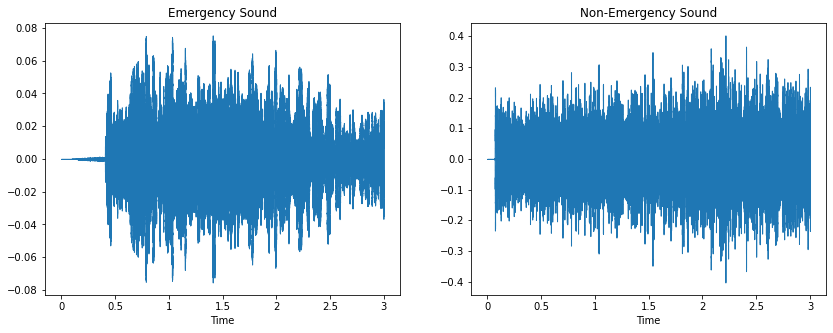

In [37]:
# Plot the audio files
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
librosa.display.waveshow(emergency, sr=sr)
plt.title('Emergency Sound')
plt.subplot(1, 2, 2)
librosa.display.waveshow(non_emergency, sr=sr)
plt.title('Non-Emergency Sound')
plt.show()

Not much to see here, just a bunch of audio files.

### Frequency Domain

In [38]:
# Frequency domain representation of the emergency sound and non-emergency sound
# Compute the Fast Fourier Transform (FFT) of the audio
fft_emergency = np.fft.fft(emergency)
fft_non_emergency = np.fft.fft(non_emergency)

# Compute the magnitude of the FFT
magnitude_emergency = np.abs(fft_emergency)
magnitude_non_emergency = np.abs(fft_non_emergency)

# Frequency of each component in Hz
f = np.linspace(0, sr, len(magnitude_emergency))

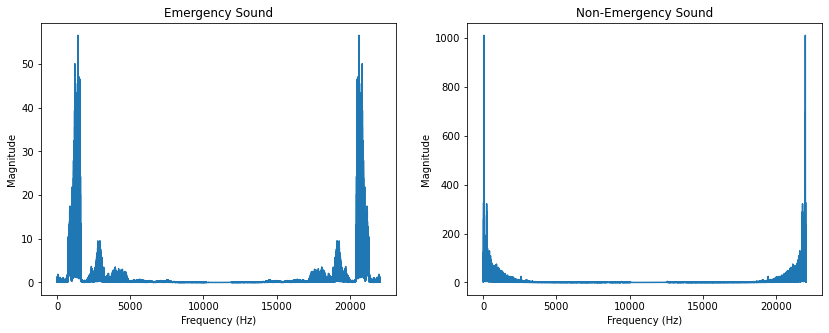

In [39]:
# Plot the frequency spectrum
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(f, magnitude_emergency)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('Emergency Sound')
plt.subplot(1, 2, 2)
plt.plot(f, magnitude_non_emergency)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('Non-Emergency Sound')
plt.show()

The frequency domain is much more interesting. We can see that the emergency audio files have a much higher frequency than the non-emergency audio files.

### Spectrogram Domain (Time-Frequency Domain)

#### Spectrogram

In [40]:
# Spectrogram of the emergency sound and non-emergency sound
# Compute the spectrogram of the audio
spectrum_emergency = np.abs(librosa.stft(emergency))
spectrum_non_emergency = np.abs(librosa.stft(non_emergency))

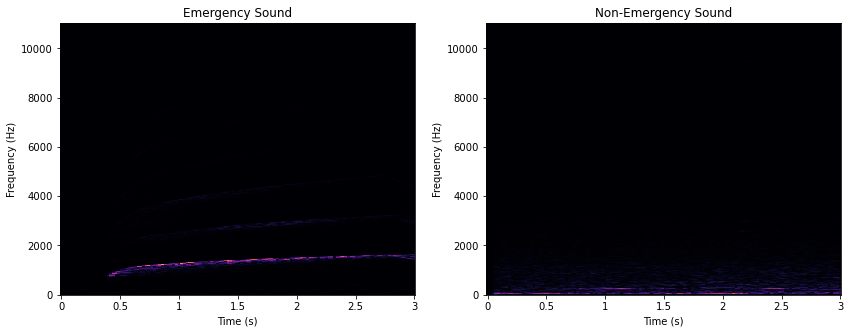

In [41]:
# Plot the spectrogram
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
librosa.display.specshow(spectrum_emergency, sr=sr, x_axis='time', y_axis='hz')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('Emergency Sound')
plt.subplot(1, 2, 2)
librosa.display.specshow(spectrum_non_emergency, sr=sr, x_axis='time', y_axis='hz')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('Non-Emergency Sound')
plt.show()

#### MFCC

In [42]:
# Mel-frequency cepstral coefficients (MFCCs)
# Extract the MFCCs
mfcc_emergency = librosa.feature.mfcc(emergency)
mfcc_non_emergency = librosa.feature.mfcc(non_emergency)

C:\Users\dikib\AppData\Local\Temp/ipykernel_7952/1296774215.py:3: FutureWarning: Pass y=[0.         0.         0.         ... 0.02308656 0.020012   0.01103913] as keyword args. From version 0.10 passing these as positional arguments will result in an error
  mfcc_emergency = librosa.feature.mfcc(emergency)
C:\Users\dikib\AppData\Local\Temp/ipykernel_7952/1296774215.py:4: FutureWarning: Pass y=[ 0.          0.          0.         ... -0.13293335 -0.11833936
 -0.10440459] as keyword args. From version 0.10 passing these as positional arguments will result in an error
  mfcc_non_emergency = librosa.feature.mfcc(non_emergency)


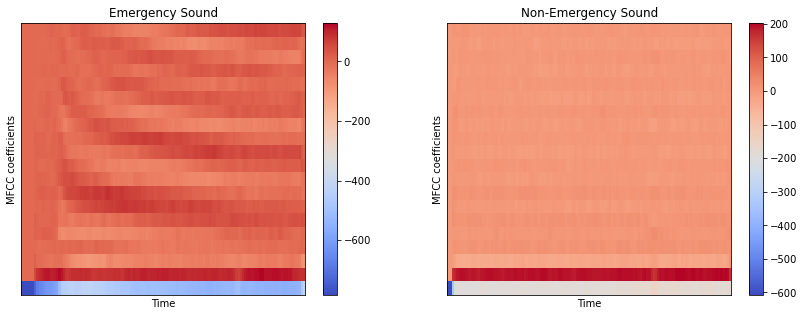

In [43]:
# Display the MFCCs
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
librosa.display.specshow(mfcc_emergency)
plt.xlabel('Time')
plt.ylabel('MFCC coefficients')
plt.title('Emergency Sound')
plt.colorbar()
plt.subplot(1, 2, 2)
librosa.display.specshow(mfcc_non_emergency)
plt.xlabel('Time')
plt.ylabel('MFCC coefficients')
plt.title('Non-Emergency Sound')
plt.colorbar()
plt.show()

#### Mel Spectrogram

In [44]:
# Mel Spectrogram
# Extract the Mel Spectrogram
ms_emergency = librosa.feature.melspectrogram(emergency)
ms_non_emergency = librosa.feature.melspectrogram(non_emergency)

C:\Users\dikib\AppData\Local\Temp/ipykernel_7952/3960920108.py:3: FutureWarning: Pass y=[0.         0.         0.         ... 0.02308656 0.020012   0.01103913] as keyword args. From version 0.10 passing these as positional arguments will result in an error
  ms_emergency = librosa.feature.melspectrogram(emergency)
C:\Users\dikib\AppData\Local\Temp/ipykernel_7952/3960920108.py:4: FutureWarning: Pass y=[ 0.          0.          0.         ... -0.13293335 -0.11833936
 -0.10440459] as keyword args. From version 0.10 passing these as positional arguments will result in an error
  ms_non_emergency = librosa.feature.melspectrogram(non_emergency)


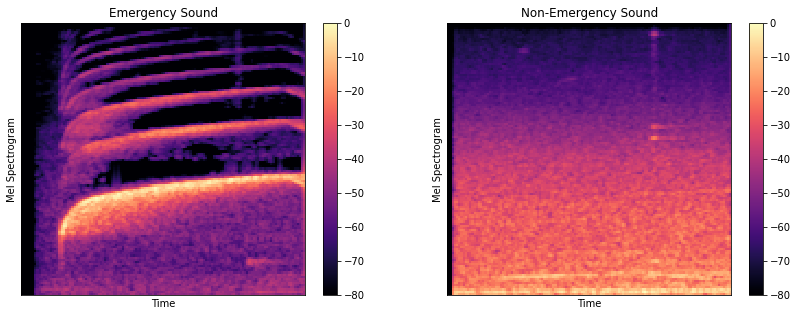

In [45]:
# Display the Mel Spectrogram
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
librosa.display.specshow(librosa.power_to_db(ms_emergency, ref=np.max))
plt.xlabel('Time')
plt.ylabel('Mel Spectrogram')
plt.title('Emergency Sound')
plt.colorbar()
plt.subplot(1, 2, 2)
librosa.display.specshow(librosa.power_to_db(ms_non_emergency, ref=np.max))
plt.xlabel('Time')
plt.ylabel('Mel Spectrogram')
plt.title('Non-Emergency Sound')
plt.colorbar()
plt.show()

Here's where things get interesting. We can see that from analyzing time-frequency domain, there's a huge difference between emergency and non-emergency audio files. The emergency audio files have a much higher frequency than the non-emergency audio files. This is a good sign that we can use this to classify emergency and non-emergency audio files by using these features as inputs to a machine learning model.

## Data Preprocessing

### Data Augmentation

In [46]:
# Augmenting functions
def add_noise(signal):
    noise = np.random.randn(len(signal))
    noise_signal = signal + 0.005 * noise
    return noise_signal

def shift(signal):
    return np.roll(signal, 1600)

def stretch(signal, rate=0.8):
    return librosa.effects.time_stretch(signal, rate)

In [47]:
# Testing the augmenting functions
# Add noise
noise_emergency = add_noise(emergency)

# Shift the audio
shift_emergency = shift(emergency)

# Stretch the audio
stretch_emergency = stretch(emergency)

C:\Users\dikib\AppData\Local\Temp/ipykernel_7952/4274662670.py:11: FutureWarning: Pass rate=0.8 as keyword args. From version 0.10 passing these as positional arguments will result in an error
  return librosa.effects.time_stretch(signal, rate)


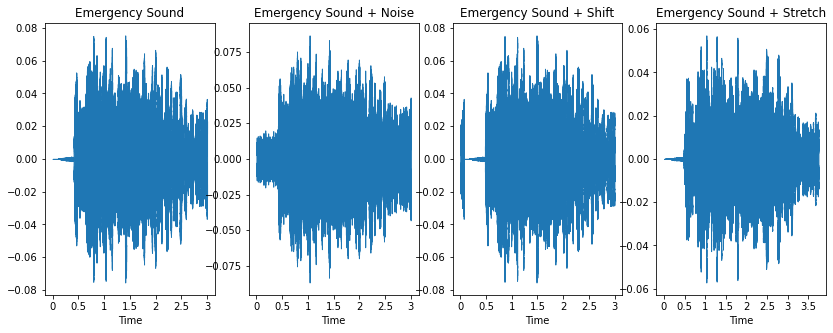

In [48]:
# Plot the audio
plt.figure(figsize=(14, 5))
plt.subplot(1, 4, 1)
librosa.display.waveshow(emergency, sr=sr)
plt.title('Emergency Sound')
plt.subplot(1, 4, 2)
librosa.display.waveshow(noise_emergency, sr=sr)
plt.title('Emergency Sound + Noise')
plt.subplot(1, 4, 3)
librosa.display.waveshow(shift_emergency, sr=sr)
plt.title('Emergency Sound + Shift')
plt.subplot(1, 4, 4)
librosa.display.waveshow(stretch_emergency, sr=sr)
plt.title('Emergency Sound + Stretch')
plt.show()

In [49]:
# Play the augmented audio
# Add noise
ipd.Audio(noise_emergency, rate=sr)

In [50]:
# Shift the audio
ipd.Audio(shift_emergency, rate=sr)

In [51]:
# Stretch the audio
ipd.Audio(stretch_emergency, rate=sr)

### Data Preparation

In [52]:
# Initialize the dataframe
# Label annotation, 0 = non-emergency, 1 = emergency
df = pd.DataFrame(columns=['signal', 'label'])

In [53]:
# Define the path to the audio files
emergency_audio_path = glob('./dataset/emergency/*.wav')
non_emergency_audio_path = glob('./dataset/non-emergency/*.wav')

In [54]:
# Add the audio signals and assign the labels
for emergency_audio in emergency_audio_path:
    signal, sr = librosa.load(emergency_audio)
    df.loc[len(df)] = [signal, 1]

for non_emergency_audio in non_emergency_audio_path:
    signal, sr = librosa.load(non_emergency_audio)
    df.loc[len(df)] = [signal, 0]

In [55]:
df

,signal,label
0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1
1,"[-6.214049e-05, -9.345361e-05, -6.516957e-05, ...",1
2,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1
3,"[-0.032152344, 0.0028992137, -0.048407882, -0....",1
4,"[0.2607958, 0.35347039, 0.20466022, 0.11311894...",1
...,...,...
995,"[0.0007953993, 0.016493868, 0.025731942, 0.027...",0
996,"[0.0008008636, 0.010126503, 0.025674632, 0.045...",0
997,"[-0.008738654, 0.0015984675, 0.024057182, 0.03...",0
998,"[-0.029727146, -0.033623997, -0.007992181, 0.0...",0


In [56]:
# Augment the audio files
for i in range(0, len(df)):
    # Add noise
    df.loc[len(df)] = [add_noise(df['signal'][i]), df['label'][i]]

    # Shift the audio
    df.loc[len(df)] = [shift(df['signal'][i]), df['label'][i]]

    # Stretch the audio
    df.loc[len(df)] = [stretch(df['signal'][i]), df['label'][i]]

C:\Users\dikib\AppData\Local\Temp/ipykernel_7952/4274662670.py:11: FutureWarning: Pass rate=0.8 as keyword args. From version 0.10 passing these as positional arguments will result in an error
  return librosa.effects.time_stretch(signal, rate)


In [57]:
df

,signal,label
0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1
1,"[-6.214049e-05, -9.345361e-05, -6.516957e-05, ...",1
2,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1
3,"[-0.032152344, 0.0028992137, -0.048407882, -0....",1
4,"[0.2607958, 0.35347039, 0.20466022, 0.11311894...",1
...,...,...
3995,"[-0.019998511, -0.035862498, -0.04710313, -0.0...",0
3996,"[-0.029766236, -0.03386253, -0.008271959, 0.00...",0
3997,"[-0.013998818468653237, -0.006591378511712118,...",0
3998,"[0.086297035, 0.0671722, 0.04822918, 0.0334221...",0


## Feature Extraction

In [58]:
# Extracting features from the y=signal, sr=sr files
def extract_features(signal):
    features = []

    ## Time-domain features
    # ZCR
    zcr = np.mean(librosa.feature.zero_crossing_rate(y=signal).T, axis=0)

    # RMS
    rms = np.mean(librosa.feature.rms(y=signal).T, axis=0)

    ## Frequency-domain features
    # Spectral Centroid
    spec_cent = np.mean(librosa.feature.spectral_centroid(y=signal, sr=sr).T, axis=0)

    # Spectral Bandwidth
    spec_bw = np.mean(librosa.feature.spectral_bandwidth(y=signal, sr=sr).T, axis=0)

    # Spectral Roll-off
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=signal, sr=sr).T, axis=0)
    
    ## Time-frequency domain features
    # Chroma
    stft = np.abs(librosa.stft(y=signal))
    chroma = np.mean(librosa.feature.chroma_stft(S=stft, sr=sr).T, axis=0)

    # MFCC
    mfcc = np.mean(librosa.feature.mfcc(y=signal, sr=sr).T, axis=0)

    # MelSpectrogram
    mel = np.mean(librosa.feature.melspectrogram(y=signal, sr=sr).T, axis=0)

    # Contrast
    contrast = np.mean(librosa.feature.spectral_contrast(S=stft, sr=sr).T, axis=0)

    # Tonnetz
    tonnetz = np.mean(librosa.feature.tonnetz(y=librosa.effects.harmonic(y=signal), sr=sr).T, axis=0)
    
    features.extend(
        [
            zcr,
            rms,
            spec_cent,
            spec_bw,
            rolloff,
            chroma,
            mfcc,
            mel,
            contrast,
            tonnetz,
        ]
    )

    return features

In [59]:
# Extracting features for each signal
df['features'] = df['signal'].apply(lambda x: extract_features(x))

c:\Users\dikib\anaconda3\lib\site-packages\librosa\util\decorators.py:88: UserWarning: Trying to estimate tuning from empty frequency set.
  return f(*args, **kwargs)
c:\Users\dikib\anaconda3\lib\site-packages\librosa\util\decorators.py:88: UserWarning: Trying to estimate tuning from empty frequency set.
  return f(*args, **kwargs)


In [60]:
df

,signal,label,features
0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,"[[0.13004056490384616], [0.016322851], [1882.2..."
1,"[-6.214049e-05, -9.345361e-05, -6.516957e-05, ...",1,"[[0.12743389423076923], [0.016226849], [1926.7..."
2,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,"[[0.1251915564903846], [0.19594102], [2228.536..."
3,"[-0.032152344, 0.0028992137, -0.048407882, -0....",1,"[[0.1277794471153846], [0.19286361], [2017.839..."
4,"[0.2607958, 0.35347039, 0.20466022, 0.11311894...",1,"[[0.10299353966346154], [0.24993902], [1634.52..."
...,...,...,...
3995,"[-0.019998511, -0.035862498, -0.04710313, -0.0...",0,"[[0.05330528846153846], [0.059206903], [1058.8..."
3996,"[-0.029766236, -0.03386253, -0.008271959, 0.00...",0,"[[0.056565272955246916], [0.040002223], [1071...."
3997,"[-0.013998818468653237, -0.006591378511712118,...",0,"[[0.06398737980769231], [0.061987085960522055]..."
3998,"[0.086297035, 0.0671722, 0.04822918, 0.0334221...",0,"[[0.05391000600961538], [0.061772786], [1106.2..."


## Feature Engineering

In [61]:
# Copy the dataframe
df_copy = df.copy()

In [62]:
df_copy

,signal,label,features
0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,"[[0.13004056490384616], [0.016322851], [1882.2..."
1,"[-6.214049e-05, -9.345361e-05, -6.516957e-05, ...",1,"[[0.12743389423076923], [0.016226849], [1926.7..."
2,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,"[[0.1251915564903846], [0.19594102], [2228.536..."
3,"[-0.032152344, 0.0028992137, -0.048407882, -0....",1,"[[0.1277794471153846], [0.19286361], [2017.839..."
4,"[0.2607958, 0.35347039, 0.20466022, 0.11311894...",1,"[[0.10299353966346154], [0.24993902], [1634.52..."
...,...,...,...
3995,"[-0.019998511, -0.035862498, -0.04710313, -0.0...",0,"[[0.05330528846153846], [0.059206903], [1058.8..."
3996,"[-0.029766236, -0.03386253, -0.008271959, 0.00...",0,"[[0.056565272955246916], [0.040002223], [1071...."
3997,"[-0.013998818468653237, -0.006591378511712118,...",0,"[[0.06398737980769231], [0.061987085960522055]..."
3998,"[0.086297035, 0.0671722, 0.04822918, 0.0334221...",0,"[[0.05391000600961538], [0.061772786], [1106.2..."


In [63]:
# Dropping the signal column
df_copy.drop(['signal'], axis=1, inplace=True)

In [64]:
df_copy

,label,features
0,1,"[[0.13004056490384616], [0.016322851], [1882.2..."
1,1,"[[0.12743389423076923], [0.016226849], [1926.7..."
2,1,"[[0.1251915564903846], [0.19594102], [2228.536..."
3,1,"[[0.1277794471153846], [0.19286361], [2017.839..."
4,1,"[[0.10299353966346154], [0.24993902], [1634.52..."
...,...,...
3995,0,"[[0.05330528846153846], [0.059206903], [1058.8..."
3996,0,"[[0.056565272955246916], [0.040002223], [1071...."
3997,0,"[[0.06398737980769231], [0.061987085960522055]..."
3998,0,"[[0.05391000600961538], [0.061772786], [1106.2..."


In [65]:
# Split the features according to its type
def split_features(dataframe):
    # Copy the dataframe
    df_copy = dataframe.copy()

    # Split the single dimensional features according to its type
    df_copy['zcr'] = df_copy['features'].apply(lambda x: float(x[0]))
    df_copy['rms'] = df_copy['features'].apply(lambda x: float(x[1]))
    df_copy['spec_cent'] = df_copy['features'].apply(lambda x: float(x[2]))
    df_copy['spec_bw'] = df_copy['features'].apply(lambda x: float(x[3]))
    df_copy['rolloff'] = df_copy['features'].apply(lambda x: float(x[4]))

    # Split the two dimensional features according to its type
    df_chroma = pd.DataFrame(df_copy['features'].apply(lambda x: x[5]).tolist(), columns=[f"chroma{i}" for i in range(12)])
    df_mfcc = pd.DataFrame(df_copy['features'].apply(lambda x: x[6]).tolist(), columns=[f"mfcc{i}" for i in range(20)])
    df_mel = pd.DataFrame(df_copy['features'].apply(lambda x: x[7]).tolist(), columns=[f"mel{i}" for i in range(128)])
    df_contrast = pd.DataFrame(df_copy['features'].apply(lambda x: x[8]).tolist(), columns=[f"contrast{i}" for i in range(7)])
    df_tonnetz = pd.DataFrame(df_copy['features'].apply(lambda x: x[9]).tolist(), columns=[f"tonnetz{i}" for i in range(6)])

    # Concatenate the features into a single dataframe
    df_features = pd.concat(
        [
            df_copy['zcr'],
            df_copy['rms'],
            df_copy['spec_cent'],
            df_copy['spec_bw'],
            df_copy['rolloff'],
            df_chroma,
            df_mfcc,
            df_mel,
            df_contrast,
            df_tonnetz,
        ],
        axis=1,
    )

    return df_features

In [66]:
# Split the features for each signal
df_split = split_features(df_copy)

In [67]:
df_split

,zcr,rms,spec_cent,spec_bw,rolloff,chroma0,chroma1,chroma2,chroma3,chroma4,...,contrast3,contrast4,contrast5,contrast6,tonnetz0,tonnetz1,tonnetz2,tonnetz3,tonnetz4,tonnetz5
0,0.130041,0.016323,1882.210327,1333.028640,3006.283616,0.205162,0.225204,0.264359,0.305373,0.318554,...,31.915013,34.800137,38.290109,55.617367,0.040713,0.024461,0.049337,-0.055911,0.025315,0.005176
1,0.127434,0.016227,1926.737413,1405.361426,3124.384953,0.233384,0.247812,0.304642,0.327444,0.355111,...,31.795842,32.070341,36.981984,55.295886,0.041697,0.018376,0.051232,-0.064749,0.026372,0.007551
2,0.125192,0.195941,2228.536708,2154.212801,4551.456581,0.507237,0.533283,0.550340,0.566979,0.582866,...,18.202129,15.533248,14.747504,54.017153,0.013756,-0.019307,0.032622,-0.038849,0.006218,-0.001260
3,0.127779,0.192864,2017.839941,1892.542241,3509.829289,0.251954,0.279349,0.365274,0.463445,0.516898,...,23.953848,18.295315,17.533376,54.119956,0.004231,-0.031239,0.015465,-0.004058,-0.001712,0.003399
4,0.102994,0.249939,1634.523635,1580.783375,2465.717398,0.240601,0.256917,0.243024,0.259694,0.270361,...,27.341440,21.558184,21.027276,53.883353,-0.003764,-0.003760,-0.028474,-0.055089,-0.006742,0.001775
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,0.053305,0.059207,1058.819818,1356.337659,1913.307918,0.878634,0.835595,0.776115,0.788314,0.817653,...,13.869216,17.435944,17.264633,49.232471,0.016433,-0.003484,-0.013024,0.044393,0.004610,-0.005125
3996,0.056565,0.040002,1071.115148,1358.969330,1924.363878,0.857033,0.865656,0.786015,0.757883,0.799426,...,14.936777,18.379655,18.024159,50.689006,0.018920,0.001510,-0.007981,0.074070,0.002321,-0.007516
3997,0.063987,0.061987,1733.495357,2426.686830,3221.367188,0.859018,0.837816,0.821001,0.798269,0.803174,...,14.025254,16.547875,13.987222,13.304703,-0.056954,0.010036,-0.002636,-0.001755,0.006726,0.013319
3998,0.053910,0.061773,1106.276459,1410.558984,1936.497521,0.850812,0.829282,0.811646,0.783266,0.785619,...,14.148936,16.936672,16.910737,49.023343,-0.057512,0.007787,0.001897,-0.002187,0.006598,0.012165


In [68]:
# Concatenate the split features with the labels
df_final = pd.concat([df_split, df_copy['label']], axis=1)

In [69]:
df_final

,zcr,rms,spec_cent,spec_bw,rolloff,chroma0,chroma1,chroma2,chroma3,chroma4,...,contrast4,contrast5,contrast6,tonnetz0,tonnetz1,tonnetz2,tonnetz3,tonnetz4,tonnetz5,label
0,0.130041,0.016323,1882.210327,1333.028640,3006.283616,0.205162,0.225204,0.264359,0.305373,0.318554,...,34.800137,38.290109,55.617367,0.040713,0.024461,0.049337,-0.055911,0.025315,0.005176,1
1,0.127434,0.016227,1926.737413,1405.361426,3124.384953,0.233384,0.247812,0.304642,0.327444,0.355111,...,32.070341,36.981984,55.295886,0.041697,0.018376,0.051232,-0.064749,0.026372,0.007551,1
2,0.125192,0.195941,2228.536708,2154.212801,4551.456581,0.507237,0.533283,0.550340,0.566979,0.582866,...,15.533248,14.747504,54.017153,0.013756,-0.019307,0.032622,-0.038849,0.006218,-0.001260,1
3,0.127779,0.192864,2017.839941,1892.542241,3509.829289,0.251954,0.279349,0.365274,0.463445,0.516898,...,18.295315,17.533376,54.119956,0.004231,-0.031239,0.015465,-0.004058,-0.001712,0.003399,1
4,0.102994,0.249939,1634.523635,1580.783375,2465.717398,0.240601,0.256917,0.243024,0.259694,0.270361,...,21.558184,21.027276,53.883353,-0.003764,-0.003760,-0.028474,-0.055089,-0.006742,0.001775,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,0.053305,0.059207,1058.819818,1356.337659,1913.307918,0.878634,0.835595,0.776115,0.788314,0.817653,...,17.435944,17.264633,49.232471,0.016433,-0.003484,-0.013024,0.044393,0.004610,-0.005125,0
3996,0.056565,0.040002,1071.115148,1358.969330,1924.363878,0.857033,0.865656,0.786015,0.757883,0.799426,...,18.379655,18.024159,50.689006,0.018920,0.001510,-0.007981,0.074070,0.002321,-0.007516,0
3997,0.063987,0.061987,1733.495357,2426.686830,3221.367188,0.859018,0.837816,0.821001,0.798269,0.803174,...,16.547875,13.987222,13.304703,-0.056954,0.010036,-0.002636,-0.001755,0.006726,0.013319,0
3998,0.053910,0.061773,1106.276459,1410.558984,1936.497521,0.850812,0.829282,0.811646,0.783266,0.785619,...,16.936672,16.910737,49.023343,-0.057512,0.007787,0.001897,-0.002187,0.006598,0.012165,0


In [70]:
df_final.describe()

,zcr,rms,spec_cent,spec_bw,rolloff,chroma0,chroma1,chroma2,chroma3,chroma4,...,contrast3,contrast4,contrast5,contrast6,tonnetz0,tonnetz1,tonnetz2,tonnetz3,tonnetz4,tonnetz5
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.122912,0.111356,2105.146164,1950.531493,3857.451041,0.594260,0.587100,0.582072,0.576553,0.570547,...,18.803531,19.237328,18.576889,41.544689,0.000919,0.004655,0.000323,0.008793,0.001062,0.000550
std,0.089503,0.089581,1042.682550,620.491817,1999.243818,0.244661,0.237213,0.235899,0.221943,0.218512,...,5.573657,4.574729,4.530083,16.254087,0.057324,0.050480,0.074112,0.074144,0.029481,0.026627
min,0.001993,0.000511,164.604732,187.786911,300.218709,0.026615,0.023634,0.017523,0.012788,0.003876,...,8.153321,8.578753,8.451497,13.249024,-0.401820,-0.368784,-0.638311,-0.478132,-0.298118,-0.117549
25%,0.056745,0.047836,1364.480657,1454.247461,2281.270329,0.390475,0.380327,0.372833,0.396473,0.391395,...,14.281904,16.405756,15.976481,21.186456,-0.020940,-0.013943,-0.035730,-0.025731,-0.010062,-0.011615
50%,0.109556,0.086612,1882.244364,1933.435393,3401.060157,0.648110,0.634138,0.624676,0.620996,0.617407,...,16.839691,17.960138,17.393768,50.244893,-0.001149,0.005034,-0.001515,0.004856,0.002065,0.001308
75%,0.145185,0.162890,2584.099899,2379.225569,5033.402846,0.819401,0.805777,0.792521,0.763807,0.749526,...,22.181751,20.981302,19.994774,52.708749,0.023141,0.024578,0.032884,0.039378,0.014282,0.012889
max,0.607955,0.518571,6160.170172,3577.372052,9393.311564,0.997007,1.000000,1.000000,0.991055,0.975691,...,47.532134,49.626797,49.417501,71.433138,0.329484,0.396742,0.312558,0.482060,0.166176,0.181193


In [71]:
# Save the dataframe to a csv file
df_final.to_csv('./extracted_features.csv', index=False)